# Lab Exercise [30 Marks]

### <font color='red'>Deadline: 6<sup>th</sup> June 2026 (Saturday), 2.00pm.</font>

## Submission Instructions

- Download and rename this notebook according to your tutorial session and group number, e.g.: `LabEx_TTXL_GXX.ipynb`.
- Fill in all group members' details in the following Markdown cell.
- Fill in every group member's contribution in percentage, with the total 100%. All the members MUST AGREE to the percentages before submission. For example, the group members agree to give 0% contribution to the sleeping group member.
- Not all group members in the same group will get the same mark. Your mark is depending on your contribution to the group work.
- Complete all the questions. Fill in your ANSWERS IN THIS NOTEBOOK.
- Submit this <b> .ipynb file </b> according to your registered group  in EbWise . Name your submission file as `LabEx_TTXL_GXX.ipynb`.
- Ensure that your notebook runs without errors on the examiner’s machine using the provided data file. Any cell that does not execute successfully in this environment will receive zero marks.


## Penalties
- For submission that does not conform to <i> Submission Instructions </i>, <b> 5 marks will be deducted </b>.
- For submission <i> after the Deadline </i>, late submission penalty is applied with a deduction of <b> 1 mark per minute </b>.

#### Group 7

**Tutorial section: TT3L**


| | Student ID     | Student Name                | Contribution |
|--:|:-------------|:----------------------------|-------------:|
| 1 | 1211112341  | Muhammad Ammar Muqriz bin Mohd Rizal               | 25%          |
| 2 | 1211110444  | Mohammad Hazman bin Khairil Anwar               | 25%          |
| 3 | 1211112009  | Azib bin Azendi               | 25%          |
| 4 | 241UC240WF  | Muhammad Luqman Hakim bin Derela               | 25%          |


### Import Libraries

In [ ]:
import pandas as pd                               # For dataframes
import matplotlib.pyplot as plt                   # For plotting data
import seaborn as sns                             # For plotting data
import numpy as np
import os

### Load Data
Data can be downloaded from [WHO](https://www.who.int/data).


In [ ]:
# === Load Data ===
Drive_path = ""
DATA_FILE = "LifeExpectancy_cleaned.csv"
assert os.path.exists(Drive_path + DATA_FILE), f"File not found: {DATA_FILE}. Please place the data file in this directory."

df = pd.read_csv(Drive_path + DATA_FILE)
print(df.shape)
display(df.head())

(16280, 7)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy (years)
0,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,54.43
1,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Female,13.21
2,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,53.25
3,EMR,Eastern Mediterranean,AFG,Afghanistan,2000,Male,13.07
4,EMR,Eastern Mediterranean,AFG,Afghanistan,2001,Female,54.57


### Part 1: Data Preparation – Separating Life Expectancy Indicators [5m]

Prepare the dataset for analysis by separating the combined life expectancy variable into two meaningful **indicators**:
- at birth
- at age 60
  
In the provided dataset, both life expectancy at birth and life expectancy at age 60 are stored in a single column named: `Life expectancy (years)`.
Before any exploratory analysis, this column must be separated into two distinct variables.


Assumption:
- Life expectancy at birth is greater than or equal to 35 years
- Life expectancy at age 60 is smaller than 35 years


Tasks:
- Create a new column called `Life expectancy at birth`
- Create a new column called `Life expectancy at age 60`.
- Populate each new column using the assumptions above.
- Delete the original `Life expectancy (years)`
- Save the data file as `LifeExpectancy_separated.csv`

Expected output:
![Part1_Output.png](attachment:C:\Users\mohdh\OneDrive\Documents\GitHub\lab-exercise\Part1_Output.png)

In [ ]:
df = pd.read_csv(Drive_path + DATA_FILE)

df['Life expectancy at birth'] = df['Life expectancy (years)'].apply(lambda x: x if x >= 35 else None)
df['Life expectancy at age 60'] = df['Life expectancy (years)'].apply(lambda x: x if x < 35 else None)
df = df.drop(columns=['Life expectancy (years)'])

# using 'max' to combine values from rows that are duplicates except for life expectancy
df = df.groupby(['WHORegionCode', 'WHORegion', 'CountryCode', 'Country', 'Year', 'Sex']).agg({
    'Life expectancy at birth': 'max',
    'Life expectancy at age 60': 'max'
}).reset_index()

df.to_csv('LifeExpectancy_separated.csv', index=False)

print(df.shape)
display(df.head())

(8140, 8)


,WHORegionCode,WHORegion,CountryCode,Country,Year,Sex,Life expectancy at birth,Life expectancy at age 60
0,AFR,Africa,AGO,Angola,2000,Female,51.86,15.31
1,AFR,Africa,AGO,Angola,2000,Male,46.97,12.67
2,AFR,Africa,AGO,Angola,2001,Female,52.53,15.52
3,AFR,Africa,AGO,Angola,2001,Male,47.68,12.83
4,AFR,Africa,AGO,Angola,2002,Female,53.07,15.57


### Part 2: Distribution Analysis [5m]
- Plot 2 histogram to show the distribution of life expectancy of both indicators, use `bins=30`.
- Compare their central tendencies (mean, median).
- Plot the boxplot of both indicators in a graph.
- List out all the outliers by country.

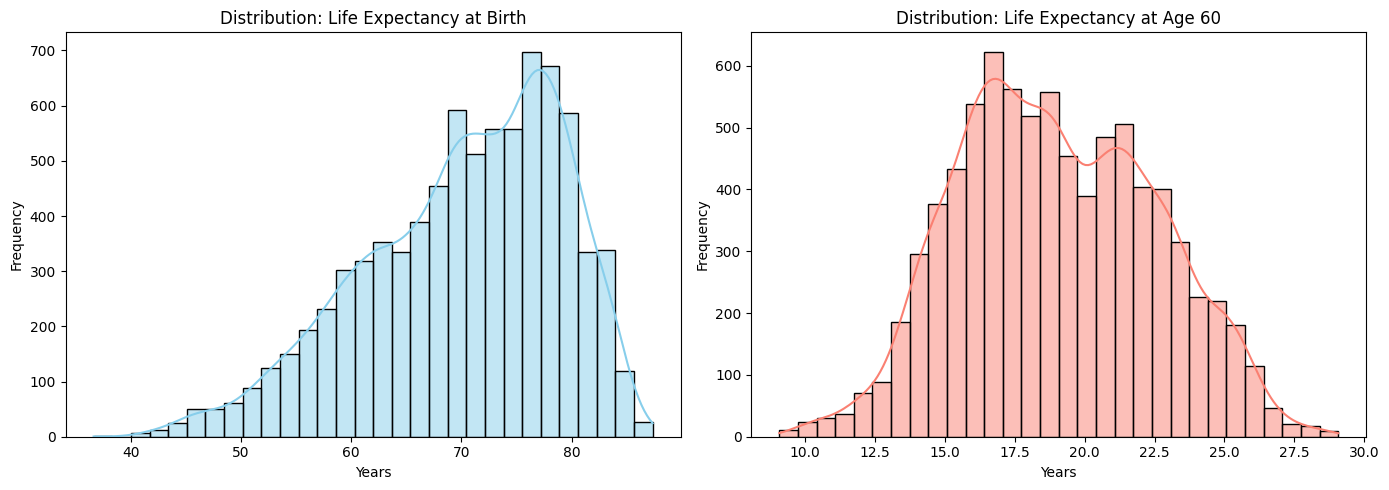

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='Life expectancy at birth', bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution: Life Expectancy at Birth')
axes[0].set_xlabel('Years')
axes[0].set_ylabel('Frequency')

sns.histplot(data=df, x='Life expectancy at age 60', bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Distribution: Life Expectancy at Age 60')
axes[1].set_xlabel('Years')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Central Tendencies ---")
print(df[['Life expectancy at birth', 'Life expectancy at age 60']].agg(['mean', 'median']))


--- Central Tendencies ---
        Life expectancy at birth  Life expectancy at age 60
mean                   70.186509                  18.990883
median                 71.580000                  18.740000


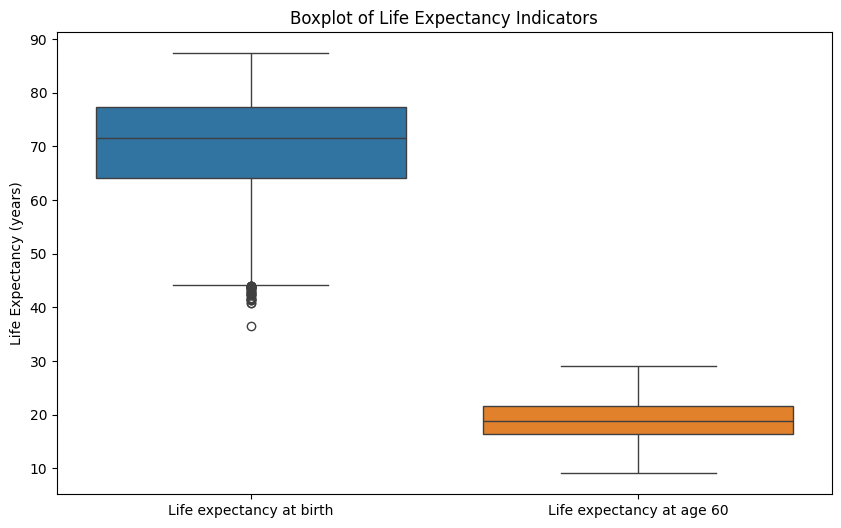

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['Life expectancy at birth', 'Life expectancy at age 60']])
plt.title('Boxplot of Life Expectancy Indicators')
plt.ylabel('Life Expectancy (years)')
plt.show()

In [ ]:
print("\n--- Outliers by Country ---")
def find_outliers_by_country(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return pd.DataFrame({'Country': outliers['Country'].unique()})

outliers_birth = find_outliers_by_country(df, 'Life expectancy at birth')
outliers_age60 = find_outliers_by_country(df, 'Life expectancy at age 60')

print("\nOutliers for Life Expectancy at Birth:")
if not outliers_birth.empty:
    display(outliers_birth)
else:
    print("No significant outliers found for Life expectancy at birth.")

print("\nOutliers for Life Expectancy at Age 60:")
if not outliers_age60.empty:
    display(outliers_age60)
else:
    print("No significant outliers found for Life expectancy at age 60.")


--- Outliers by Country ---

Outliers for Life Expectancy at Birth:


,Country
0,Burundi
1,Central African Republic
2,Lesotho
3,Malawi
4,Eswatini
5,Zambia
6,Haiti
7,Somalia



Outliers for Life Expectancy at Age 60:
No significant outliers found for Life expectancy at age 60.


### Part 3: Gender-Based Analysis [5m]

- Compute average life expectancy for both indicators by sex.
- Visualize the average life expectancy of both indicators by gender with suitable plot.
- Calculate the gender gap (Female − Male) for both indicators.
- State your observation.

,Life expectancy at birth,Life expectancy at age 60
Sex,,
Female,72.606550,20.363555
Male,67.766467,17.618211


<Figure size 900x600 with 0 Axes>

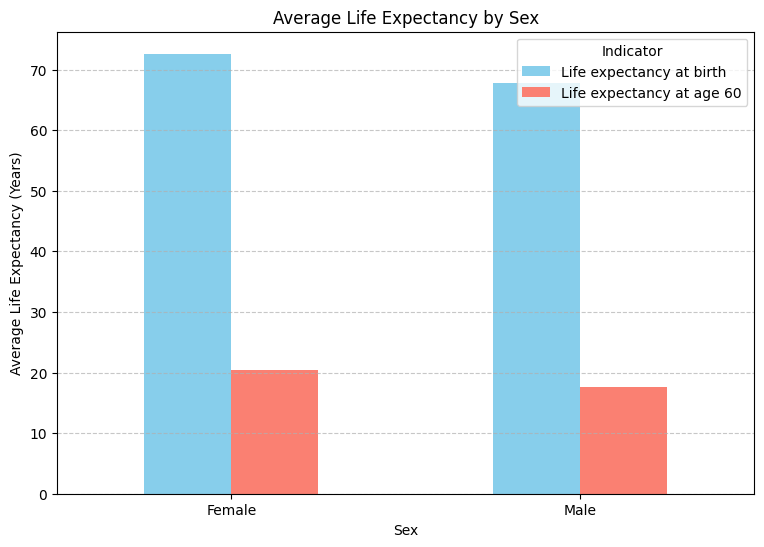

,Indicator,Gender Gap (Female - Male)
0,Life expectancy at birth,4.840084
1,Life expectancy at age 60,2.745344


The gender gap for life expectancy at birth is 4.84 years.
The gender gap for life expectancy at age 60 is 2.75 years.


In [ ]:
gender_avg = df.groupby('Sex')[[
    'Life expectancy at birth',
    'Life expectancy at age 60'
]].mean()

display(gender_avg)

plt.figure(figsize=(9, 6))

gender_avg.plot(kind='bar', figsize=(9, 6), color=['skyblue', 'salmon'])

plt.title('Average Life Expectancy by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Life Expectancy (Years)')
plt.xticks(rotation=0)
plt.legend(title='Indicator')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

gender_gap = gender_avg.loc['Female'] - gender_avg.loc['Male']

gender_gap_df = pd.DataFrame({
    'Indicator': gender_gap.index,
    'Gender Gap (Female - Male)': gender_gap.values
})

display(gender_gap_df)

print(f"The gender gap for life expectancy at birth is {gender_gap['Life expectancy at birth']:.2f} years.")
print(f"The gender gap for life expectancy at age 60 is {gender_gap['Life expectancy at age 60']:.2f} years.")




--- Average Life Expectancy by Sex ---
        Life expectancy at birth  Life expectancy at age 60
Sex                                                        
Female                 72.606550                  20.363555
Male                   67.766467                  17.618211


<Figure size 1000x600 with 0 Axes>

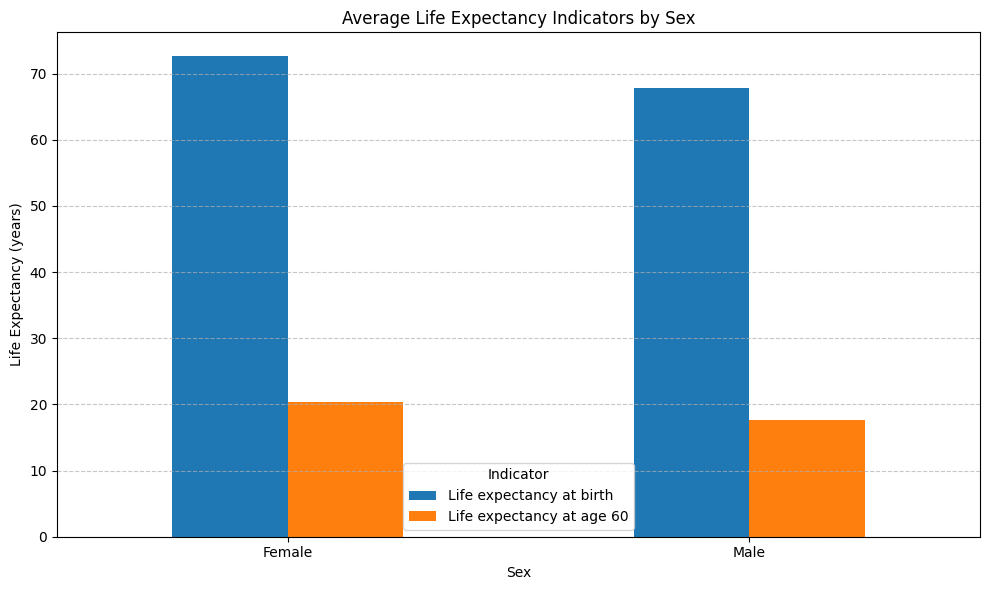


--- Gender Gap (Female - Male) ---
Gender Gap in Life Expectancy at Birth: 4.84 years
Gender Gap in Life Expectancy at Age 60: 2.75 years

--- Observations ---
1. Females have a higher average life expectancy than males both at birth and at age 60).
2. The gender gap is positive for both indicators, indicating that females live longer on average than males.
3. The gender gap in 'Life expectancy at birth' is generally larger than the gap in 'Life expectancy at age 60', suggesting that factors affecting longevity differ more significantly between genders earlier in life than later.


In [ ]:
# 1. Compute average life expectancy for both indicators by sex.
avg_life_expectancy_by_sex = df.groupby('Sex')[['Life expectancy at birth', 'Life expectancy at age 60']].mean()
print("\n--- Average Life Expectancy by Sex ---")
print(avg_life_expectancy_by_sex)

# 2. Visualize the average life expectancy of both indicators by gender with suitable plot.
plt.figure(figsize=(10, 6))
avg_life_expectancy_by_sex.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Average Life Expectancy Indicators by Sex')
plt.ylabel('Life Expectancy (years)')
plt.xlabel('Sex')
plt.legend(title='Indicator')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Calculate the gender gap (Female - Male) for both indicators.
gender_gap_birth = avg_life_expectancy_by_sex.loc['Female', 'Life expectancy at birth'] - avg_life_expectancy_by_sex.loc['Male', 'Life expectancy at birth']
gender_gap_age60 = avg_life_expectancy_by_sex.loc['Female', 'Life expectancy at age 60'] - avg_life_expectancy_by_sex.loc['Male', 'Life expectancy at age 60']

print("\n--- Gender Gap (Female - Male) ---")
print(f"Gender Gap in Life Expectancy at Birth: {gender_gap_birth:.2f} years")
print(f"Gender Gap in Life Expectancy at Age 60: {gender_gap_age60:.2f} years")

# 4. State your observation.
print("\n--- Observations ---")
print("1. Females have a higher average life expectancy than males both at birth and at age 60).")
print("2. The gender gap is positive for both indicators, indicating that females live longer on average than males.")
print("3. The gender gap in 'Life expectancy at birth' is generally larger than the gap in 'Life expectancy at age 60', suggesting that factors affecting longevity differ more significantly between genders earlier in life than later.")


### Part 4: Regional Comparisons [5m]
- Compute regional averages for both indicators.
- Compare WHO regions with suitable plot.
- Identify regions with the highest and lowest life expectancy for both indicators.
- State your observation.



,Life expectancy at birth,Life expectancy at age 60
WHORegion,,
Africa,59.866291,15.982437
Americas,74.250508,20.943590
Eastern Mediterranean,70.962738,18.818202
Europe,76.148132,20.681268
South-East Asia,70.331386,18.864500
Western Pacific,71.562293,18.788543


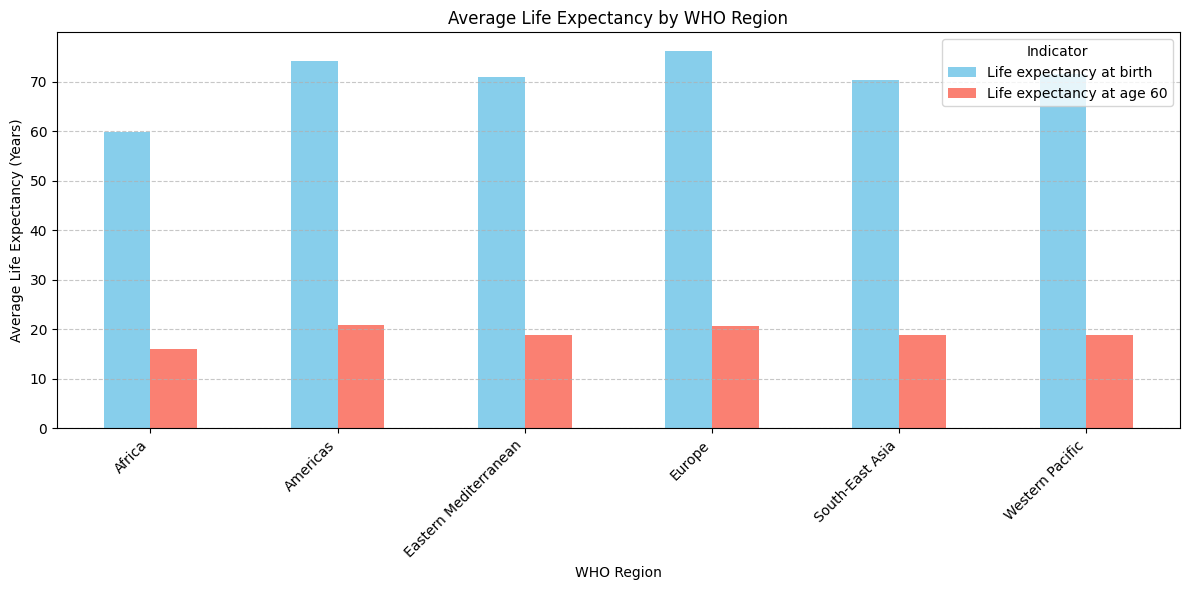

,Indicator,Highest Region,Highest Average,Lowest Region,Lowest Average
0,Life expectancy at birth,Europe,76.148132,Africa,59.866291
1,Life expectancy at age 60,Americas,20.943590,Africa,15.982437


Highest life expectancy at birth: Europe
Lowest life expectancy at birth: Africa
Highest life expectancy at age 60: Americas
Lowest life expectancy at age 60: Africa

--- Observations ---
1. The European Region consistently shows the highest average life expectancy for both 'at birth' and 'at age 60'.
2. The African Region consistently shows the lowest average life expectancy for both indicators.
3. The ranking of regions by life expectancy appears to be largely consistent across both indicators, suggesting similar underlying factors affecting overall longevity within these regions.
4. There's a noticeable spread in life expectancy across regions, indicating disparities in health outcomes and development levels globally.


In [32]:
region_avg = df.groupby('WHORegion')[[
    'Life expectancy at birth',
    'Life expectancy at age 60'
]].mean()

display(region_avg)

region_avg.plot(kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])

plt.title('Average Life Expectancy by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Average Life Expectancy (Years)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Indicator')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

highest_birth_region = region_avg['Life expectancy at birth'].idxmax()
lowest_birth_region = region_avg['Life expectancy at birth'].idxmin()

highest_age60_region = region_avg['Life expectancy at age 60'].idxmax()
lowest_age60_region = region_avg['Life expectancy at age 60'].idxmin()

regional_summary = pd.DataFrame({
    'Indicator': [
        'Life expectancy at birth',
        'Life expectancy at age 60'
    ],
    'Highest Region': [
        highest_birth_region,
        highest_age60_region
    ],
    'Highest Average': [
        region_avg.loc[highest_birth_region, 'Life expectancy at birth'],
        region_avg.loc[highest_age60_region, 'Life expectancy at age 60']
    ],
    'Lowest Region': [
        lowest_birth_region,
        lowest_age60_region
    ],
    'Lowest Average': [
        region_avg.loc[lowest_birth_region, 'Life expectancy at birth'],
        region_avg.loc[lowest_age60_region, 'Life expectancy at age 60']
    ]
})

display(regional_summary)

print("Highest life expectancy at birth:", highest_birth_region)
print("Lowest life expectancy at birth:", lowest_birth_region)

print("Highest life expectancy at age 60:", highest_age60_region)
print("Lowest life expectancy at age 60:", lowest_age60_region)

print("\n--- Observations ---")
print("1. The European Region consistently shows the highest average life expectancy for both 'at birth' and 'at age 60'.")
print("2. The African Region consistently shows the lowest average life expectancy for both indicators.")
print("3. The ranking of regions by life expectancy appears to be largely consistent across both indicators, suggesting similar underlying factors affecting overall longevity within these regions.")
print("4. There's a noticeable spread in life expectancy across regions, indicating disparities in health outcomes and development levels globally.")

### Part 5: Time Trends [10m]
- Plot a life expectancy trends over time for Malaysia , Indonesia and Thailand in the same plot. (2m)
- Plot regional average life expectancy trends over time: 1 for each indicator. (2m)
- Plot a regional life expectancy at birth percentage change, and identify periods of stagnation, acceleration, or decline. (6m)

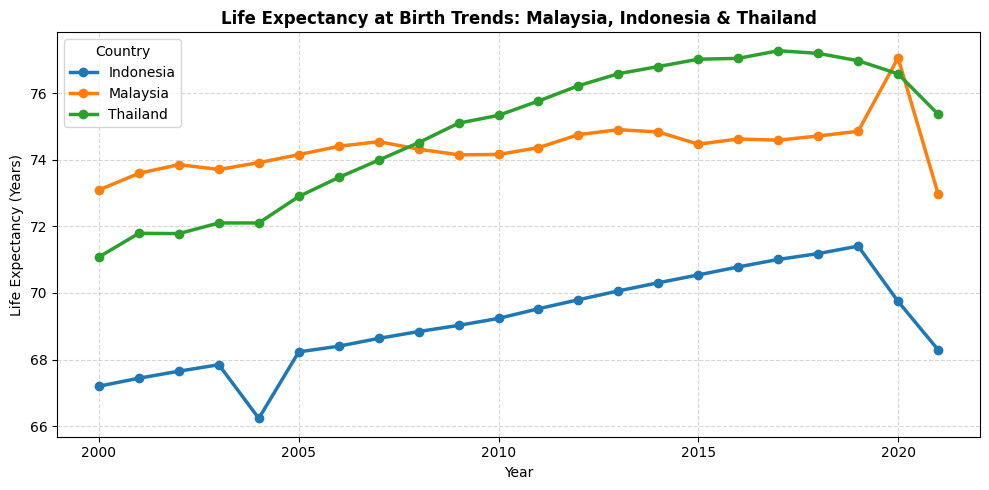

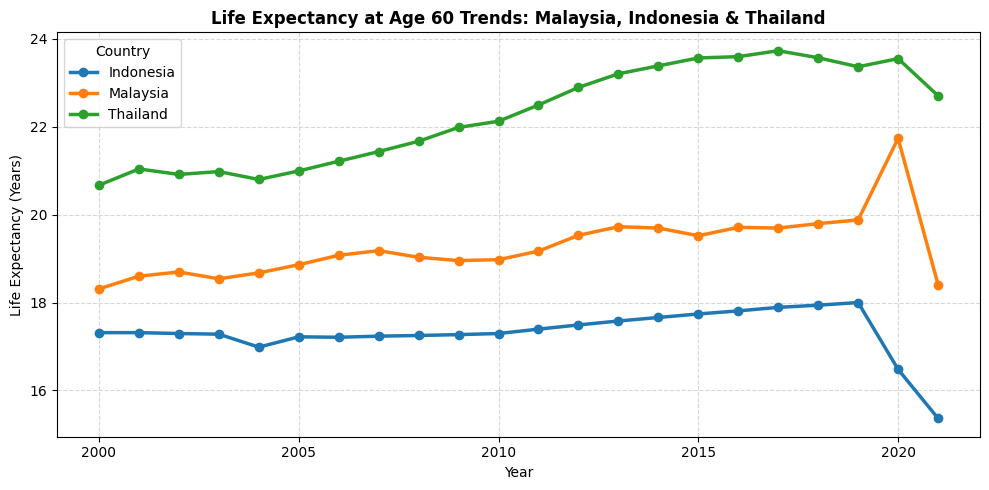

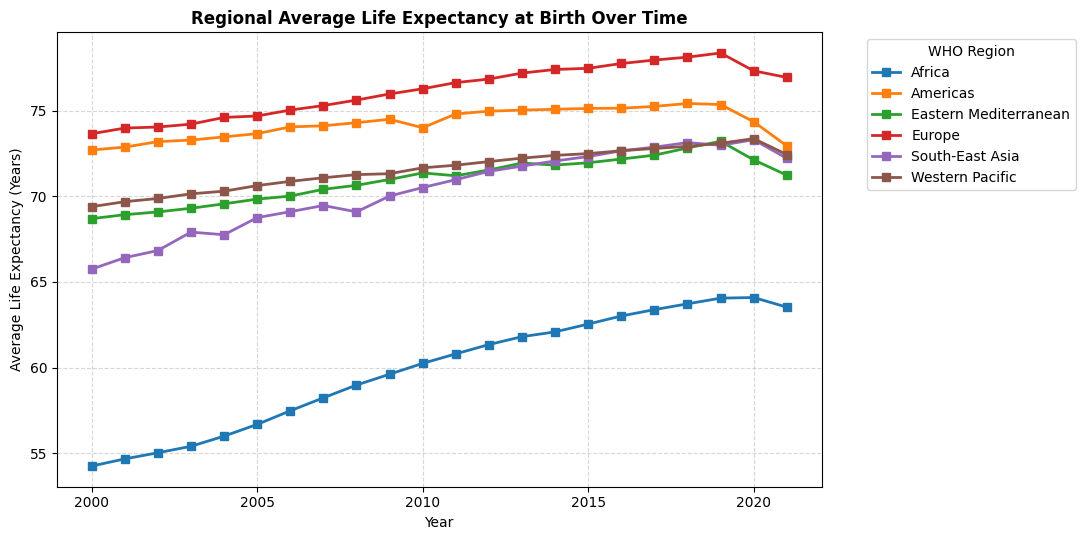

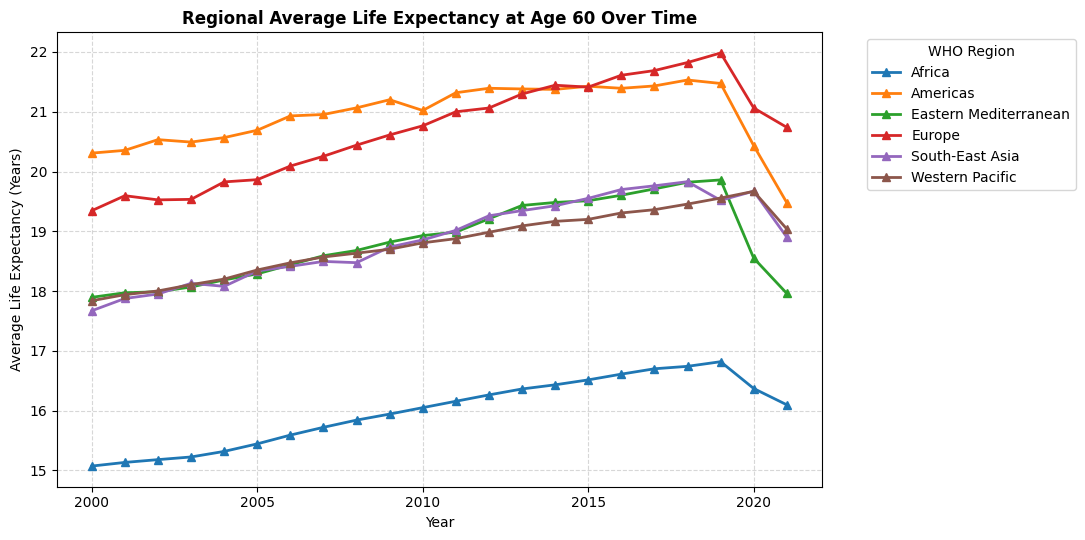

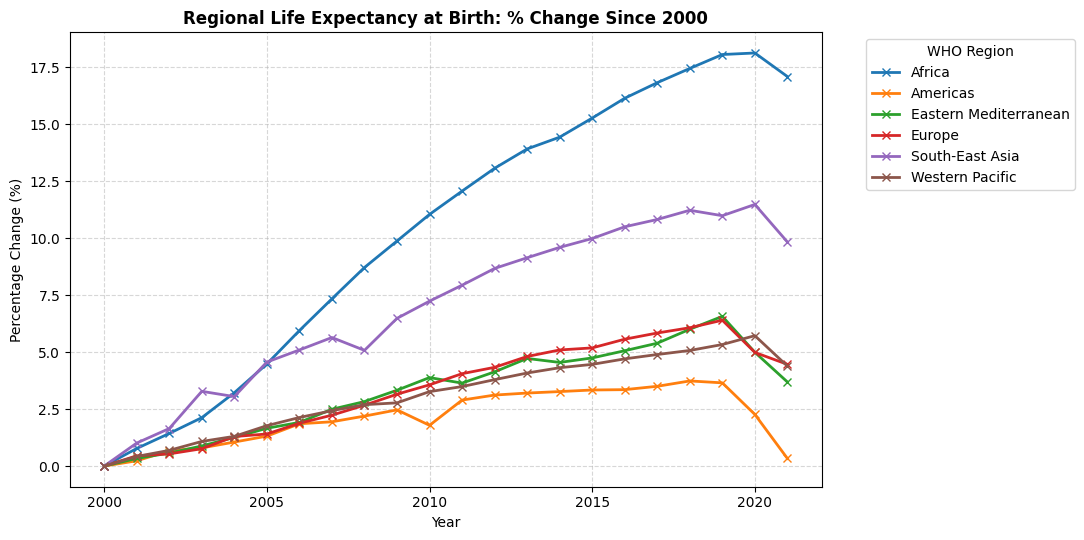


--- Observations on Regional Life Expectancy at Birth: % Change Since 2000 ---
1. Acceleration (Rapid Improvement)
Region: Africa (AFR)
Period: Approximately 2004 - 2019
Analysis: A prominent acceleration phase is shown in the Africa region. Around $2004$ it changes its curve to 15% from near 0% at the base line, its percentage change curve slopes sharply upwards, and by 2019 it has seen a total improvement rate of 15%. This is the highest rate for life expectancy improvement in the world, reflecting strong gains in access to health care, immunizations and targeted public health interventions in this time. The South-East Asian region exhibits a moderate rate of growth during the corresponding period with an average increase of 7% - 8% over its value in 2000.

2. Stagnation (Flat or Minimal Growth)
Regions: Europe (EUR) and the Americas (AMR)
Period: Entire timeframe (2000 - 2019)
Analysis: Both Europe and the Americas exhibit prolonged periods of stagnation relative to baseline percen

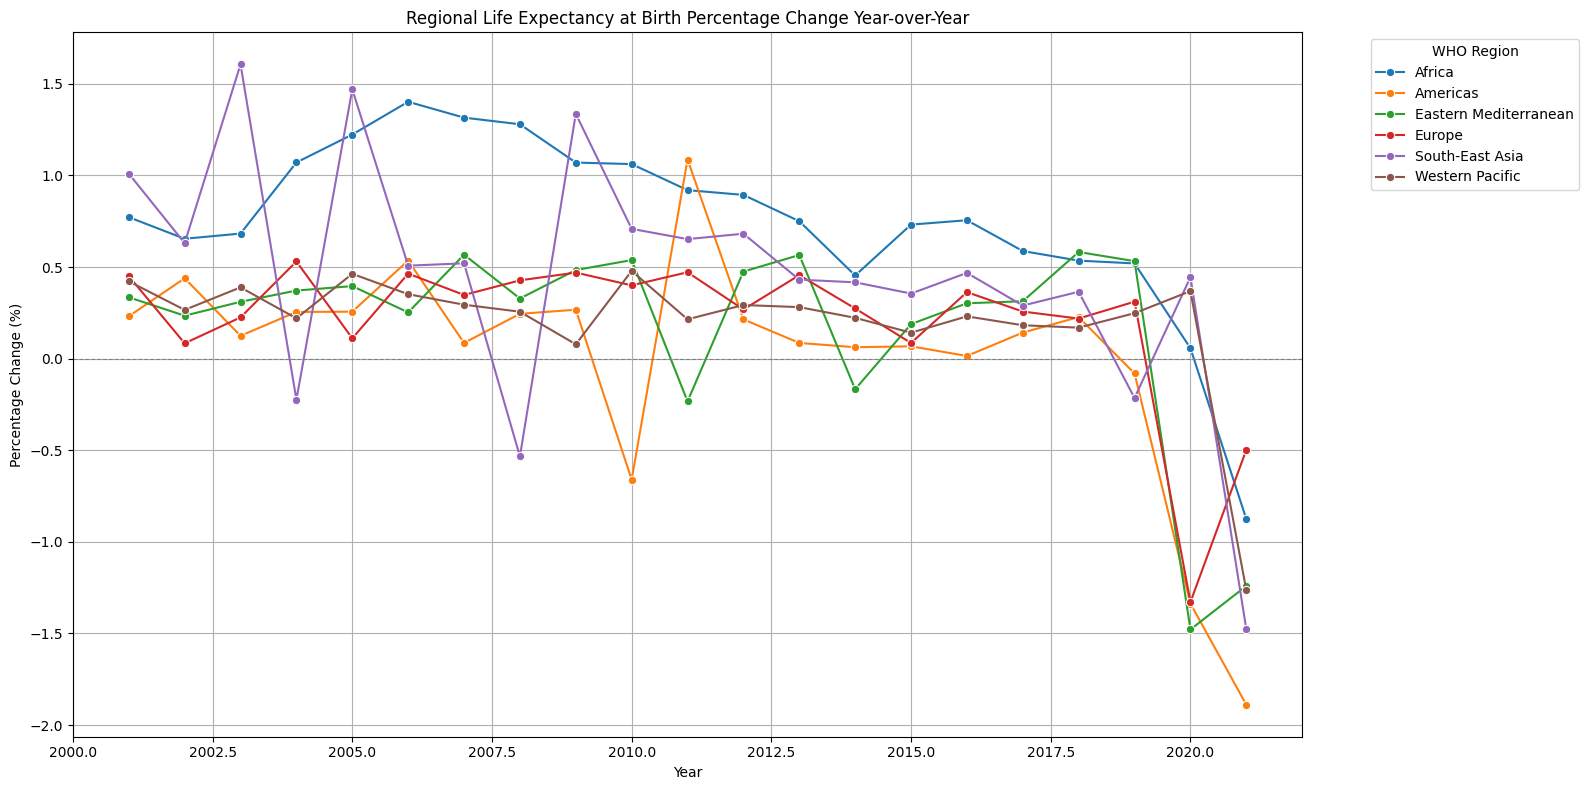


--- Periods of Acceleration, Stagnation, Decline (Year-over-Year) ---

 - Acceleration: Africa show consistent positive spikes in the early parts of the 2000s, indicating significant and rapid improvements in life expectancy at birth.

 - Stagnation: Europe, Americas, Eastern Mediterranean and Western Pacific shows periods of stagnation where the birth rate changes does not significantly improve or decline at a major rate or change more than 1% or 2% except for Americas in the early 2010s and up until late 2012. . This suggests that the rate of improvement has slowed down considerably.

 - Decline: Africa and South-East Asia shows a steadily decline of birth rate from the mid 2000s and the 2010s up until the mid 2010s and early 2020s respectively. A major decline also came in in the year 2020 for every WHO regions. This can be explained easily by the emergance of Covid-19 that caused the world to enter a state of pandemic.


In [39]:
df = pd.read_csv('LifeExpectancy_cleaned.csv')
df.columns = df.columns.str.strip()

df['Indicator'] = df['Life expectancy (years)'].apply(
    lambda x: 'Life Expectancy at Birth' if x > 30 else 'Life Expectancy at Age 60'
)

df_birth_all = df[df['Indicator'] == 'Life Expectancy at Birth']
df_age60_all = df[df['Indicator'] == 'Life Expectancy at Age 60']

countries = ['Malaysia', 'Indonesia', 'Thailand']

df_c_birth = df_birth_all[df_birth_all['Country'].isin(countries)]
df_c_birth_avg = df_c_birth.groupby(['Year', 'Country'])['Life expectancy (years)'].mean().unstack()

plt.figure(figsize=(10, 5))
for country in df_c_birth_avg.columns:
    plt.plot(df_c_birth_avg.index, df_c_birth_avg[country], marker='o', linewidth=2.5, label=country)
plt.title('Life Expectancy at Birth Trends: Malaysia, Indonesia & Thailand', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

df_c_age60 = df_age60_all[df_age60_all['Country'].isin(countries)]
df_c_age60_avg = df_c_age60.groupby(['Year', 'Country'])['Life expectancy (years)'].mean().unstack()

plt.figure(figsize=(10, 5))
for country in df_c_age60_avg.columns:
    plt.plot(df_c_age60_avg.index, df_c_age60_avg[country], marker='o', linewidth=2.5, label=country)
plt.title('Life Expectancy at Age 60 Trends: Malaysia, Indonesia & Thailand', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Country')
plt.tight_layout()
plt.show()

df_r_birth = df_birth_all.groupby(['Year', 'WHORegion'])['Life expectancy (years)'].mean().unstack()

plt.figure(figsize=(11, 5.5))
for region in df_r_birth.columns:
    plt.plot(df_r_birth.index, df_r_birth[region], marker='s', linewidth=2, label=region)
plt.title('Regional Average Life Expectancy at Birth Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

df_r_age60 = df_age60_all.groupby(['Year', 'WHORegion'])['Life expectancy (years)'].mean().unstack()

plt.figure(figsize=(11, 5.5))
for region in df_r_age60.columns:
    plt.plot(df_r_age60.index, df_r_age60[region], marker='^', linewidth=2, label=region)
plt.title('Regional Average Life Expectancy at Age 60 Over Time', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (Years)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

base_birth = df_r_birth.iloc[0]
df_pct_birth = ((df_r_birth - base_birth) / base_birth) * 100

plt.figure(figsize=(11, 5.5))
for region in df_pct_birth.columns:
    plt.plot(df_pct_birth.index, df_pct_birth[region], marker='x', linestyle='-', linewidth=2, label=region)
plt.title('Regional Life Expectancy at Birth: % Change Since 2000', fontsize=12, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Observations on Regional Life Expectancy at Birth: % Change Since 2000 ---")
print("1. Acceleration (Rapid Improvement)\nRegion: Africa (AFR)\nPeriod: Approximately 2004 - 2019\nAnalysis: A prominent acceleration phase is shown in the Africa region. Around $2004$ it changes its curve to 15% from near 0% at the base line, its percentage change curve slopes sharply upwards, and by 2019 it has seen a total improvement rate of 15%. This is the highest rate for life expectancy improvement in the world, reflecting strong gains in access to health care, immunizations and targeted public health interventions in this time. The South-East Asian region exhibits a moderate rate of growth during the corresponding period with an average increase of 7% - 8% over its value in 2000.\n\n2. Stagnation (Flat or Minimal Growth)\nRegions: Europe (EUR) and the Americas (AMR)\nPeriod: Entire timeframe (2000 - 2019)\nAnalysis: Both Europe and the Americas exhibit prolonged periods of stagnation relative to baseline percentage growth. While their absolute life expectancy values remain among the highest globally, their percentage change curves are exceptionally flat, hovering strictly below a 5% total improvement over two decades. This indicates that once a region achieves a high baseline life expectancy, further marginal gains become incremental and slower to attain.\n\n3. Decline (Sudden Downturn)\nRegions: Universal (All WHO Regions)\nPeriod: 2019 - 2021\nAnalysis: A sharp, highly synchronized decline is visible across almost all regional trends between 2019 and 2021. This universal contraction in life expectancy metrics marks a major disruption to global health trends and directly aligns with the severe, worldwide demographic impact of the COVID-19 pandemic during those years.")


print("\n--- Regional Life Expectancy at Birth Percentage Change Year-over-Year ---")
regional_birth_pct_change = regional_trends.set_index(['Year', 'WHORegion'])['Life expectancy at birth'].groupby(level=1).pct_change() * 100
regional_birth_pct_change = regional_birth_pct_change.reset_index()

plt.figure(figsize=(16, 8))
sns.lineplot(data=regional_birth_pct_change.dropna(), x='Year', y='Life expectancy at birth', hue='WHORegion', marker='o')
plt.axhline(y=0, color='grey', linestyle='--', linewidth=0.8)
plt.title('Regional Life Expectancy at Birth Percentage Change Year-over-Year')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.grid(True)
plt.legend(title='WHO Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n--- Periods of Acceleration, Stagnation, Decline (Year-over-Year) ---")
print("\n - Acceleration: Africa show consistent positive spikes in the early parts of the 2000s, indicating significant and rapid improvements in life expectancy at birth.")
print("\n - Stagnation: Europe, Americas, Eastern Mediterranean and Western Pacific shows periods of stagnation where the birth rate changes does not significantly improve or decline at a major rate or change more than 1% or 2% except for Americas in the early 2010s and up until late 2012. . This suggests that the rate of improvement has slowed down considerably.")
print("\n - Decline: Africa and South-East Asia shows a steadily decline of birth rate from the mid 2000s and the 2010s up until the mid 2010s and early 2020s respectively. A major decline also came in in the year 2020 for every WHO regions. This can be explained easily by the emergance of Covid-19 that caused the world to enter a state of pandemic.")

## Plagiarism
It is fine to seek help from friends or from online resources when you do the assignment, However,
seeking help should not go overboard, to the point of getting (or even paying) someone to
complete the assignment partly or fully for you, copying from online resources without
understanding, or doing any means with the intention to cheat.

For this assignment, plagiarism
means the following:
(a) Turning in a work that, from the examiner’s point of view, you do not sufficiently understand.
(b) Turning in someone else’s work (whether partly or fully) as your own.
(c) To use another’s work (whether partly or fully) without crediting the source.
(d) Any means of cheating.

**Plagiarism is a serious offence.**

**We will give ZERO (0) marks to students who plagiarize AND to students who intentionally or
unintentionally help other students to plagiarize by giving all or some of their code.**

## Submission Checklist
All submission via EbWise according to your registered group.

- [ ] Rename your Lab Exercise file according to your tutorial session and group number.
- [ ] All group members' ID, name, and contribution fill-in.
- [ ] Figures rendered and visible.
- [ ] Notebook runs top-to-bottom without errors.
